
# Capstone Webscraping using BeautifulSoup

This notebook contains guidances & tasks on the data processing for the application

## Background

> *Industri perfilman global terus mengalami pertumbuhan pesat, dengan data pendapatan dan peringkat film menjadi indikator penting untuk menganalisis kesuksesan dan tren pasar. Salah satu sumber utama informasi tersebut adalah situs Box Office Mojo, yang menyajikan data terkait pendapatan domestik, internasional, dan global dari berbagai film. Namun, akses terhadap data tersebut sering kali tidak disediakan dalam format yang mudah diolah secara langsung. Oleh karena itu, diperlukan pendekatan seperti web scraping untuk mengotomatisasi proses pengambilan data.* 

## Requesting the Data and Creating a BeautifulSoup

Let's start by requesting the webpage using the `get` method from the `requests` library.

In [1]:
import requests

url_get = requests.get('http://boxofficemojo.com/year/world/2024/')

To visualize what exactly you get from the `request.get`, we can use `.content` so see what we exactly get (HTML content), in here i slice it so it won't make our screen full of the html we get from the page. You can delete the slicing if you want to see what we fully get.

In [2]:
url_get.content[1:500]

b'!doctype html><html class="a-no-js" data-19ax5a9jf="dingo"><head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>\n<script type=\'text/javascript\'>var ue_t0=ue_t0||+new Date();</script>\n<script type=\'text/javascript\'>\nwindow.ue_ihb = (window.ue_ihb || window.ueinit || 0) + 1;\nif (window.ue_ihb === 1) {\n\nvar ue_csm = window,\n    ue_hob = +new Date();\n(function(d){var e=d.ue=d.ue||{},f=Date.now||function(){return+new Date};e.d=function(b){return f()-(b?0:d.ue_t0)};e.'

As we can see we get a very unstructured and complex html, which actually contains the codes needed to show the webpages on your web browser. But we as human still confused what and where we can use that piece of code, so here where we use the beautifulsoup. Beautiful soup class will result a beautifulsoup object. Beautiful Soup transforms a complex HTML document into a complex tree of Python objects. 

Let's create a BeautifulSoup object and feel free to explore the object here.

In [3]:
from bs4 import BeautifulSoup 

soup = BeautifulSoup(url_get.content,"html.parser")

## Finding the right key to scrap the data & Extracting the right information

To extract the desired information, we need to find the right key using the .find() method. We can explore the HTML structure using .prettify().

*(please change this markdown with your explanation)*

In [5]:
table = soup.find('div', attrs={'class':'a-section imdb-scroll-table-inner'})
print(table.prettify()[1:500])

div class="a-section imdb-scroll-table-inner">
 <table class="a-bordered a-horizontal-stripes a-size-base a-span12 mojo-body-table mojo-table-annotated">
  <tr>
   <th class="a-text-right mojo-field-type-rank mojo-sort-column mojo-sortable-column a-nowrap">
    <a class="a-link-normal a-nowrap" href="?sort=rank&amp;ref_=bo_ydw__resort#table" title="Rank">
     <span class="a-color-state">
      Rank
     </span>
     <span class="a-letter-space">
     </span>
     <span class="icon aok-relative


In [6]:
table2 = table.find('table', attrs={'class':'a-bordered a-horizontal-stripes a-size-base a-span12 mojo-body-table mojo-table-annotated'})
print(table2.prettify()[1:1000])

table class="a-bordered a-horizontal-stripes a-size-base a-span12 mojo-body-table mojo-table-annotated">
 <tr>
  <th class="a-text-right mojo-field-type-rank mojo-sort-column mojo-sortable-column a-nowrap">
   <a class="a-link-normal a-nowrap" href="?sort=rank&amp;ref_=bo_ydw__resort#table" title="Rank">
    <span class="a-color-state">
     Rank
    </span>
    <span class="a-letter-space">
    </span>
    <span class="icon aok-relative">
     <i class="a-icon a-icon-collapse" role="presentation">
     </i>
    </span>
   </a>
  </th>
  <th class="a-text-left mojo-field-type-release_group mojo-sortable-column a-nowrap">
   <span title="Release Group">
    Release Group
   </span>
  </th>
  <th class="a-text-right mojo-field-type-money mojo-sortable-column a-nowrap">
   <a class="a-link-normal a-nowrap" href="?sort=worldwideGrossToDate&amp;ref_=bo_ydw__resort#table" title="Worldwide">
    Worldwide
    <span class="a-letter-space">
    </span>
    <span class="icon aok-relative">
    


Next, we need to find the row length.

In [ ]:
row = table.find_all('tr')[1:] #[1:] di sini bermaksud baris yang pertama di skip.
row_length = len(row)
row_length

200

Di halaman situs [Box Office Mojo](http://boxofficemojo.com/year/world/2024/') itu ada sebuah tabel yang berisi daftar film lengkap dengan peringkat dan pendapatannya. Untuk mengambil data dari tabel itu, kita pakai teknik yang disebut **web scraping**, yang intinya kita “membaca” isi halaman web secara otomatis seperti layaknya manusia, tapi dilakukan oleh program.

Nah, kita dapat menggunakan teknil looping atau perulangan agar kita dapat mengambil data secara automatis. Di baris:
```
for row in row_length: 
    cols = row.find_all('td')
```

Lalu, di dalam setiap baris tabel itu, ada beberapa kolom (disebut td **[table data]**), dan kita ambil isi kolom tertentu menggunakan indeks angka. Misalnya:

* `cols[0] `artinya kolom pertama, berisi peringkat film,
* `cols[1]` artinya kolom kedua, berisi judul film,
* `cols[2]` berisi pendapatan global,
* `cols[3]` berisi pendapatan domestik,
* `cols[5]` berisi pendapatan internasional.

Angka indeks ini dipakai karena dalam kode pemrograman, posisi kolom dihitung mulai dari nol (0), bukan satu.

> Bagian `if len(cols) >= 6:` berfungsi untuk memastikan bahwa satu baris tabel memiliki minimal 6 kolom, agar program tidak error saat mengambil data dari kolom pendapatan dari luar negeri (yaitu `cols[5]`). Jika jumlah kolom kurang dari itu, baris tersebut akan dilewati.

Setelah datanya diambil dari kolom-kolom tersebut, semuanya dimasukkan ke dalam temp, yaitu sebuah wadah penyimpanan sementara yang isinya akan jadi kumpulan data dari semua film yang sudah kita baca tadi.

In [10]:
temp = []

row_length = table2.find_all('tr')[1:]
for row in row_length:
    cols = row.find_all('td')
    if len(cols) >= 6:
        rank = cols[0].text.strip()
        releasegroup = cols[1].text.strip()
        worldwide = cols[2].text.strip()
        domestic = cols[3].text.strip()
        foreign = cols[5].text.strip()
        temp.append((rank, releasegroup, worldwide, domestic, foreign))

temp

[('1', 'Inside Out 2', '$1,698,863,816', '$652,980,194', '$1,045,883,622'),
 ('2',
  'Deadpool & Wolverine',
  '$1,338,073,645',
  '$636,745,858',
  '$701,327,787'),
 ('3', 'Moana 2', '$1,059,242,164', '$460,405,297', '$598,836,867'),
 ('4', 'Despicable Me 4', '$969,579,672', '$361,004,205', '$608,575,467'),
 ('5', 'Wicked', '$756,085,570', '$473,231,120', '$282,854,450'),
 ('6',
  'Mufasa: The Lion King',
  '$722,631,756',
  '$254,567,693',
  '$468,064,063'),
 ('7', 'Dune: Part Two', '$714,644,358', '$282,144,358', '$432,500,000'),
 ('8',
  'Godzilla x Kong: The New Empire',
  '$571,850,016',
  '$196,350,016',
  '$375,500,000'),
 ('9', 'Kung Fu Panda 4', '$547,689,492', '$193,590,620', '$354,098,872'),
 ('10',
  'Sonic the Hedgehog 3',
  '$492,162,604',
  '$236,115,100',
  '$256,047,504'),
 ('11',
  'Venom: The Last Dance',
  '$478,937,618',
  '$139,755,882',
  '$339,181,736'),
 ('12', 'Gladiator II', '$462,180,717', '$172,438,016', '$289,742,701'),
 ('13',
  'Beetlejuice Beetlejuice'

Note: You can customize the code inside the loop according to your needs to extract the desired information from the website you scrap. Make sure to check and adjust the code well to suit the HTML structure and information you want to retrieve.

## Creating data frame & Data wrangling

Once we have extracted the data, we can put it into a dataframe.

In [11]:
import pandas as pd

df = pd.DataFrame(temp, columns = ('rank', 'releasegroup', 'worldwide', 'domestic', 'foreign'))
df.head()

,rank,releasegroup,worldwide,domestic,foreign
0,1,Inside Out 2,"$1,698,863,816","$652,980,194","$1,045,883,622"
1,2,Deadpool & Wolverine,"$1,338,073,645","$636,745,858","$701,327,787"
2,3,Moana 2,"$1,059,242,164","$460,405,297","$598,836,867"
3,4,Despicable Me 4,"$969,579,672","$361,004,205","$608,575,467"
4,5,Wicked,"$756,085,570","$473,231,120","$282,854,450"


### Data Cleansing

> Sebelum kita mengolah dan memvisualisasikan datanya, kita perlu membersihkannya terlebih dahulu **(data cleansing)**. Dalam hal ini, kita menghapus simbol dolar `($)` dan tanda koma `(,)` dari kolom-kolom pendapatan seperti worldwide, domestic, dan foreign menggunakan fungsi str.replace(), karena simbol-simbol tersebut bukan bagian dari nilai numerik. Selain itu, terlihat data `worldwide, domestic, dan foreign` yang kosong terisi dengan **`(-)`** sehingga perlu kita ubah menjadi **`0`**. Setelah itu, kita mengubah tipe data yang belum sesuai.

In [ ]:
# Hapus ($) dan juga (,) 
df['worldwide'] = df['worldwide'].str.replace(r'[$,]', '', regex=True)
df['domestic'] = df['domestic'].str.replace(r'[$,]', '', regex=True)
df['foreign'] = df['foreign'].str.replace(r'[$,]', '', regex=True)

df

,rank,releasegroup,worldwide,domestic,foreign
0,1,Inside Out 2,1698863816,652980194,1045883622
1,2,Deadpool & Wolverine,1338073645,636745858,701327787
2,3,Moana 2,1059242164,460405297,598836867
3,4,Despicable Me 4,969579672,361004205,608575467
4,5,Wicked,756085570,473231120,282854450
...,...,...,...,...,...
195,196,Rafadan Tayfa: Kapadokya,9898425,-,9898425
196,197,Io e te dobbiamo parlare,9886115,-,9886115
197,198,Listy do M. Pozegnania i powroty,9782064,-,9782064
198,199,The Chosen: S4 Episodes 4-6,9482744,9482744,-


In [15]:
# Ubah data yang kosong
df['worldwide'] = df['worldwide'].str.replace('-', '0', regex=False)
df['domestic'] = df['domestic'].str.replace('-', '0', regex=False)
df['foreign'] = df['foreign'].str.replace('-', '0', regex=False)

df

,rank,releasegroup,worldwide,domestic,foreign
0,1,Inside Out 2,1698863816,652980194,1045883622
1,2,Deadpool & Wolverine,1338073645,636745858,701327787
2,3,Moana 2,1059242164,460405297,598836867
3,4,Despicable Me 4,969579672,361004205,608575467
4,5,Wicked,756085570,473231120,282854450
...,...,...,...,...,...
195,196,Rafadan Tayfa: Kapadokya,9898425,0,9898425
196,197,Io e te dobbiamo parlare,9886115,0,9886115
197,198,Listy do M. Pozegnania i powroty,9782064,0,9782064
198,199,The Chosen: S4 Episodes 4-6,9482744,9482744,0


In [13]:
# Cek tipe datanya
df.dtypes

rank            object
releasegroup    object
worldwide       object
domestic        object
foreign         object
dtype: object

In [16]:
df['rank'] = df['rank'].astype('int64')
df['worldwide'] = df['worldwide'].astype('int64')
df['domestic'] = df['domestic'].astype('int64')
df['foreign'] = df['foreign'].astype('int64')

In [17]:
df.dtypes

rank             int64
releasegroup    object
worldwide        int64
domestic         int64
foreign          int64
dtype: object

In [25]:
# Set rank menjadi Index
df = df.set_index('rank')
df

,releasegroup,worldwide,domestic,foreign
rank,,,,
1,Inside Out 2,1698863816,652980194,1045883622
2,Deadpool & Wolverine,1338073645,636745858,701327787
3,Moana 2,1059242164,460405297,598836867
4,Despicable Me 4,969579672,361004205,608575467
5,Wicked,756085570,473231120,282854450
...,...,...,...,...
196,Rafadan Tayfa: Kapadokya,9898425,0,9898425
197,Io e te dobbiamo parlare,9886115,0,9886115
198,Listy do M. Pozegnania i powroty,9782064,0,9782064


### Data Visualization

> Kita diminta untuk menampilkan 10 film terpopuler pada tahun 2024. Jadi, kita hanya mengambil top 10 film pada tahun 2024 yang dapat dilakukan dengan metode `head(10)`.

In [26]:
# Top 10 Film pada tahun 2024
top10film = df.head(10)
top10film

,releasegroup,worldwide,domestic,foreign
rank,,,,
1,Inside Out 2,1698863816,652980194,1045883622
2,Deadpool & Wolverine,1338073645,636745858,701327787
3,Moana 2,1059242164,460405297,598836867
4,Despicable Me 4,969579672,361004205,608575467
5,Wicked,756085570,473231120,282854450
6,Mufasa: The Lion King,722631756,254567693,468064063
7,Dune: Part Two,714644358,282144358,432500000
8,Godzilla x Kong: The New Empire,571850016,196350016,375500000
9,Kung Fu Panda 4,547689492,193590620,354098872


In [30]:
# Menggunakan style dari library Matplotlib
import matplotlib.pyplot as plt
print(plt.style.available)
plt.style.use('seaborn-v0_8')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Implementing your webscrapping to the flask dashboard

- Copy paste all of your web scrapping process to the desired position on the `app.py`
- Change the title of the dashboard in `index.html`

## Finishing This Notebook with Your Analysis and Conclusion

First you can do start with making the data visualization.

<Axes: title={'center': 'Top 10 Film in 2024'}, xlabel='Pendapatan', ylabel='Film'>

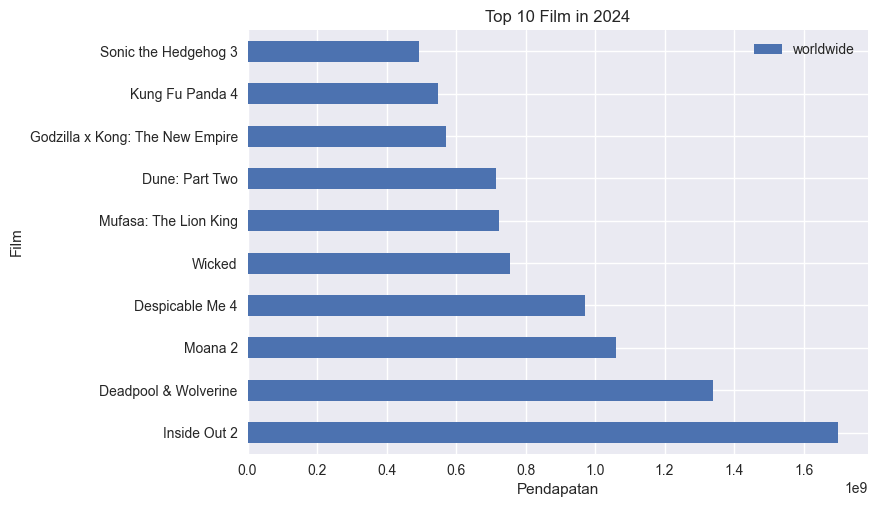

In [44]:
# Visualisasi Pendapatan Global Top 10 Film 2024
top10film.plot(kind='barh', x = 'releasegroup', y = 'worldwide', title='Top 10 Film in 2024', ylabel='Film', xlabel = 'Pendapatan')

<Axes: title={'center': 'Top 10 Film in 2024'}, xlabel='Pendapatan', ylabel='Film'>

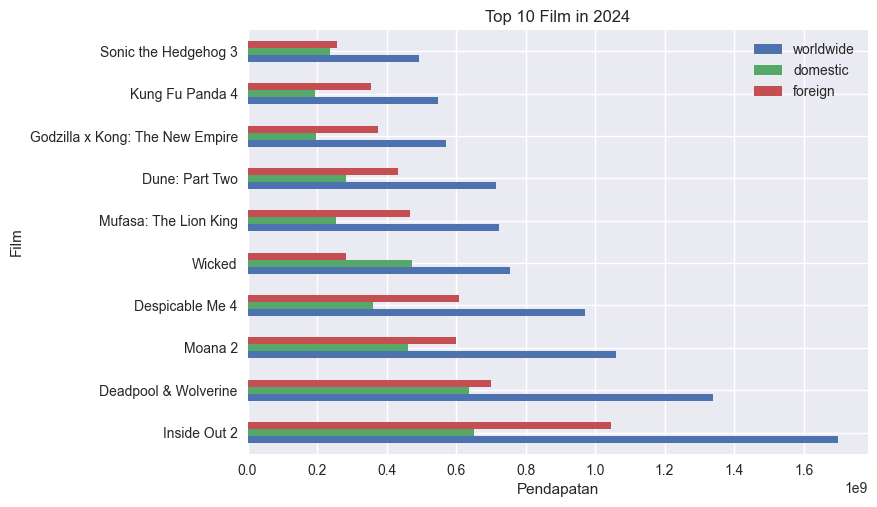

In [45]:
# Visualisasi Proporsi Pendapatan Top 10 Film 2024
top10film.plot(kind='barh', x = 'releasegroup', y = ['worldwide', 'domestic', 'foreign'], title='Top 10 Film in 2024', ylabel='Film', xlabel = 'Pendapatan')

In [46]:
# Visualisasi Pendapatan Global Top 10 Film 2024 Menggunakan Plotly Express
import plotly_express as px
fig = px.bar(
    top10film,
    y='releasegroup',
    x=['worldwide', 'domestic', 'foreign'],
    orientation='h',
    title='Top 10 Film Worldwide 2024',
)


fig.update_layout(yaxis=dict(autorange="reversed"))  # agar urutan tetap atas ke bawah
fig

## Analysis

> * Film Inside Out 2 adalah film terpopuler pada tahun 2024.

> * Top 10 Film pada tahun 2024 didominasi oleh film animasi (Inside Out 2, Moana 2, Despicable Me 4, dll.)

> * Top 10 Film pada tahun 2024 juga didominasi oleh film sekuel dan waralaba.

> * Kontribusi pasar internasional sangat besar sehingga mendominasi pendapatan film.

### Extra Challange

This will be not included to the scoring. 

- You can create additional visualization/analysis from the data.
- Implement it to the dashboard with at `app.py` dan `index.html`.